# GSS 

### Problem Tanımı ve Veri Kalitesi

In [10]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

İlgili kütüphaneler yüklendi.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv("gss_2010_ve_sonrasi.csv")

removed_cols = ["natfare"]
df = df.drop(columns=removed_cols)

categorical_cols = ["sex", "race", "income", "health", "satfin"]
df[categorical_cols] = df[categorical_cols].astype("category")

print(f"Veri yüklendi. Satır sayısı: {df.shape[0]}, sütun sayısı: {df.shape[1]}")
print("Projeden çıkarılan sütunlar:", ", ".join(removed_cols))
print("Kategoriye çevrilen sütunlar:", ", ".join(categorical_cols))
print("Güncel veri tipleri:")
print(df[categorical_cols].dtypes)

Veri yüklendi. Satır sayısı: 22656, sütun sayısı: 8
Projeden çıkarılan sütunlar: natfare
Kategoriye çevrilen sütunlar: sex, race, income, health, satfin
Güncel veri tipleri:
sex       category
race      category
income    category
health    category
satfin    category
dtype: object


Veri yüklendi ve `natfare` sütunu projeden çıkarıldı. Böylece analiz, eksik oranı çok yüksek olan alanı dışarıda bırakarak daha güvenilir bir temel üzerinde ilerliyor.

In [4]:
print(f"Veri boyutu: {df.shape}")

Veri boyutu: (22656, 8)


Satır ve sütun sayısı, veri setinin beklenen ölçekte olduğunu doğruladı. Bu büyüklük, hem hızlı keşif analizi hem de daha sonra yapılacak veri temizliği için yönetilebilir bir çalışma alanı sağlıyor.

In [5]:
print("df.info()")
df.info()

print("\ndf.describe()")
display(df.describe())

print("\ndf.sample()")
display(df.sample(5, random_state=42))

df.info()
<class 'pandas.DataFrame'>
RangeIndex: 22656 entries, 0 to 22655
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   year    22656 non-null  float64 
 1   id      22656 non-null  float64 
 2   educ    22527 non-null  float64 
 3   sex     22525 non-null  category
 4   race    22484 non-null  category
 5   income  20175 non-null  category
 6   health  18606 non-null  category
 7   satfin  22564 non-null  category
dtypes: category(5), float64(3)
memory usage: 641.9 KB

df.describe()


,year,id,educ
count,22656.000000,22656.000000,22527.000000
mean,2018.090219,1538.280235,13.998935
std,4.534804,1007.249467,2.994875
min,2010.000000,1.000000,0.000000
25%,2014.000000,716.000000,12.000000
50%,2018.000000,1432.000000,14.000000
75%,2022.000000,2196.250000,16.000000
max,2024.000000,4471.000000,20.000000



df.sample()


,year,id,educ,sex,race,income,health,satfin
8280,2016.0,1725.0,12.0,2.0,2.0,12.0,NaN,2.0
22486,2024.0,3140.0,14.0,1.0,1.0,12.0,2.0,2.0
11788,2021.0,21.0,14.0,2.0,1.0,NaN,3.0,2.0
15643,2021.0,4290.0,14.0,2.0,2.0,10.0,2.0,3.0
6760,2016.0,205.0,16.0,1.0,1.0,12.0,2.0,2.0


`df.info()` kalan sütunların yapısını gösterdi; `natfare` analizden çıkarıldığı için tablo daha temiz hale geldi. Geriye kalan alanlarda özellikle `income`, `health` ve `sex` gibi değişkenlerin kodlu kategori mantığıyla okunması gerektiği yine netleşti.

In [6]:
missing_summary = df.isnull().sum().to_frame("eksik_sayi")
missing_summary["eksik_oran_%"] = (missing_summary["eksik_sayi"] / len(df) * 100).round(2)
display(missing_summary.sort_values("eksik_oran_%", ascending=False))

,eksik_sayi,eksik_oran_%
health,4050,17.88
income,2481,10.95
race,172,0.76
sex,131,0.58
educ,129,0.57
satfin,92,0.41
year,0,0.00
id,0,0.00


In [7]:
df.sample(5, random_state=42)

,year,id,educ,sex,race,income,health,satfin
8280,2016.0,1725.0,12.0,2.0,2.0,12.0,NaN,2.0
22486,2024.0,3140.0,14.0,1.0,1.0,12.0,2.0,2.0
11788,2021.0,21.0,14.0,2.0,1.0,NaN,3.0,2.0
15643,2021.0,4290.0,14.0,2.0,2.0,10.0,2.0,3.0
6760,2016.0,205.0,16.0,1.0,1.0,12.0,2.0,2.0


Eksik veri tablosu artık `natfare` hariç kalan alanlara odaklanıyor. Bu yaklaşım, yarısından fazlası eksik olan bir sütunu doldurmaya çalışmak yerine, karar kalitesini bozmayacak değişkenlerle devam etmeyi sağlar.

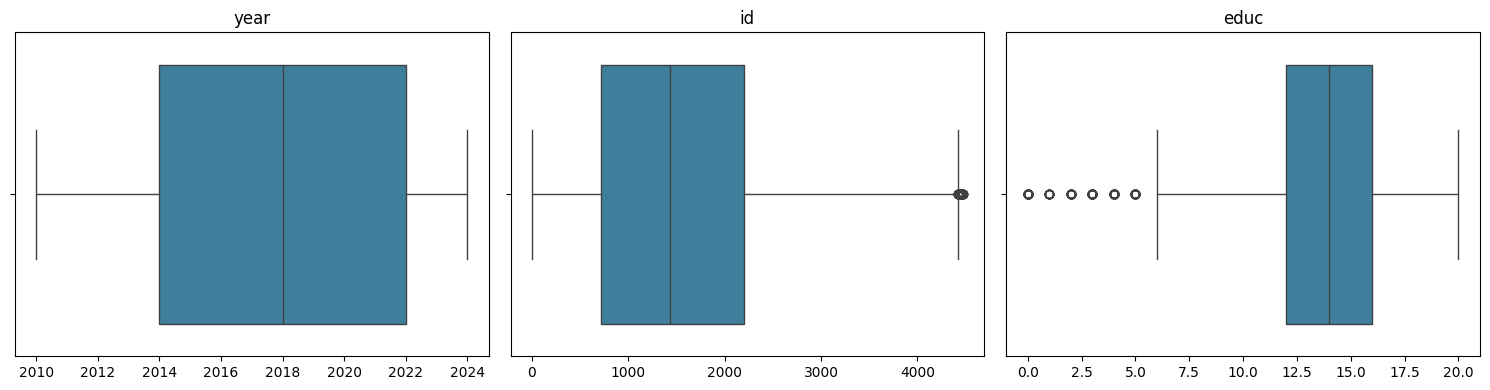

,sütun,aykiri_sayi,alt_sinir,ust_sinir
2,educ,207,6.000,22.000
1,id,48,-1504.375,4416.625
0,year,0,2002.000,2034.000


In [48]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

cols_per_row = 3
rows = (len(numeric_cols) + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax, color="#2E86AB")
    ax.set_title(col)
    ax.set_xlabel("")

for ax in axes[len(numeric_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

outlier_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        "sütun": col,
        "aykiri_sayi": int(outlier_count),
        "alt_sinir": lower,
        "ust_sinir": upper,
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("aykiri_sayi", ascending=False)
display(outlier_summary)

# Bu kısımdaki veri doldurma işlemini
X_train X_test y_train y_test ayrımından sonra yapmak daha iyi olacaktır. Bu şekilde modele mod ve medyanın kopyasını veriyoruz. trainin modunu traine fit teste transform yapmalıyız.


Boxplot artık `natfare` hariç kalan sayısal alanlar için çiziliyor. Bu da aykırı değer yorumunu, eksikliği çok yüksek olan bir sütunun gürültüsünden arındırılmış şekilde yapmamızı sağlıyor.

Bu analizden çıkan pratik sonuç şu: `natfare` projeden çıkarıldı; kalan alanlarda düşük eksiklikte silme yapılabilir, kritik kodlu alanlarda tahminleme daha uygundur, ortalama ile doldurma ise ancak son çare olarak düşünülmelidir. Özellikle `health` ve `income` gibi alanlarda yöntem seçimi, raporun doğruluğunu doğrudan etkiler.

`income` için medyan, `health` için mod seçildi. Bu tercih, sıralı/kodlu yapıda olan alanlarda dağılımı daha az bozar ve raporlamayı daha dengeli tutar. Bundan sonraki işlemler de dosyanın en altına eklenecek.

In [49]:
income_median = df["income"].dropna().astype(float).median()
health_mode = df["health"].mode(dropna=True).iloc[0]

if income_median not in df["income"].cat.categories:
    df["income"] = df["income"].cat.add_categories([income_median])
df["income"] = df["income"].fillna(income_median)

if health_mode not in df["health"].cat.categories:
    df["health"] = df["health"].cat.add_categories([health_mode])
df["health"] = df["health"].fillna(health_mode)

print(f"income eksikleri medyan ile dolduruldu: {income_median}")
print(f"health eksikleri mod ile dolduruldu: {health_mode}")
print("Güncel eksik sayıları:")
print(df[["income", "health"]].isnull().sum())

income eksikleri medyan ile dolduruldu: 12.0
health eksikleri mod ile dolduruldu: 2.0
Güncel eksik sayıları:
income    0
health    0
dtype: int64


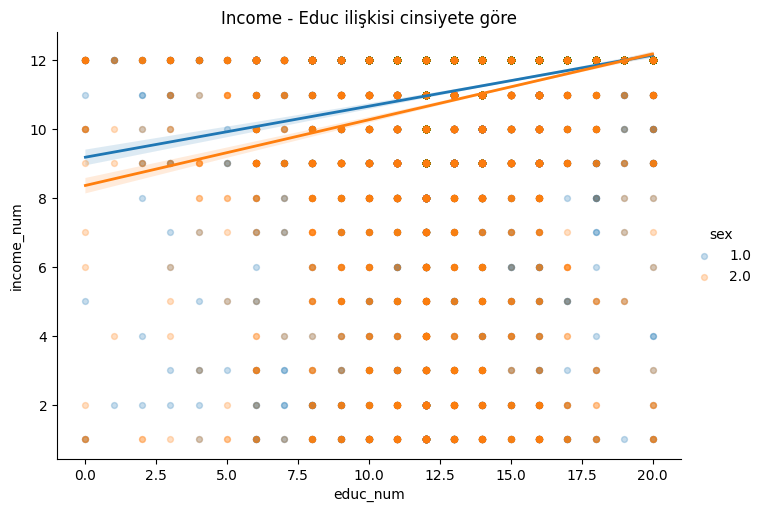

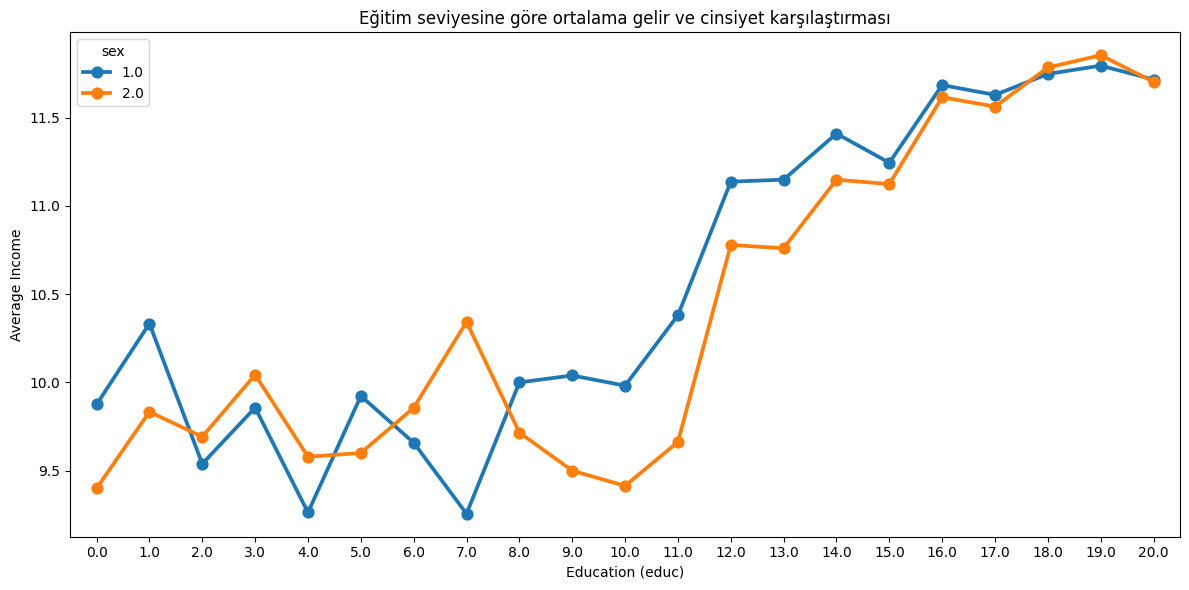

In [50]:
plot_df = df.copy()
plot_df["income_num"] = plot_df["income"].astype(float)
plot_df["educ_num"] = plot_df["educ"].astype(float)

sns.lmplot(
    data=plot_df,
    x="educ_num",
    y="income_num",
    hue="sex",
    height=5,
    aspect=1.4,
    scatter_kws={"alpha": 0.25, "s": 18},
    line_kws={"linewidth": 2},
)
plt.title("Income - Educ ilişkisi cinsiyete göre")
plt.show()

plt.figure(figsize=(12, 6))
sns.pointplot(
    data=plot_df,
    x="educ_num",
    y="income_num",
    hue="sex",
    errorbar=None,
)
plt.title("Eğitim seviyesine göre ortalama gelir ve cinsiyet karşılaştırması")
plt.xlabel("Education (educ)")
plt.ylabel("Average Income")
plt.tight_layout()
plt.show()

Bu görseller, eğitim seviyesi arttıkça gelirin genel olarak yükseldiğini ama cinsiyet grupları arasında tam örtüşme olmadığını gösterir. Yani aynı eğitim düzeyinde bile cinsiyete bağlı küçük farklar olabilir; bu da hipotezin tamamen reddedilmemesi gerektiğini, ancak etkinin eğitim kadar güçlü görünmediğini düşündürür.
Hipotez : Aynı eğitim seviyesinde (educ) olunsa bile, cinsiyet (sex) veya ırk (race) gelir (income) üzerinde belirleyici bir etkiye sahip midir?"

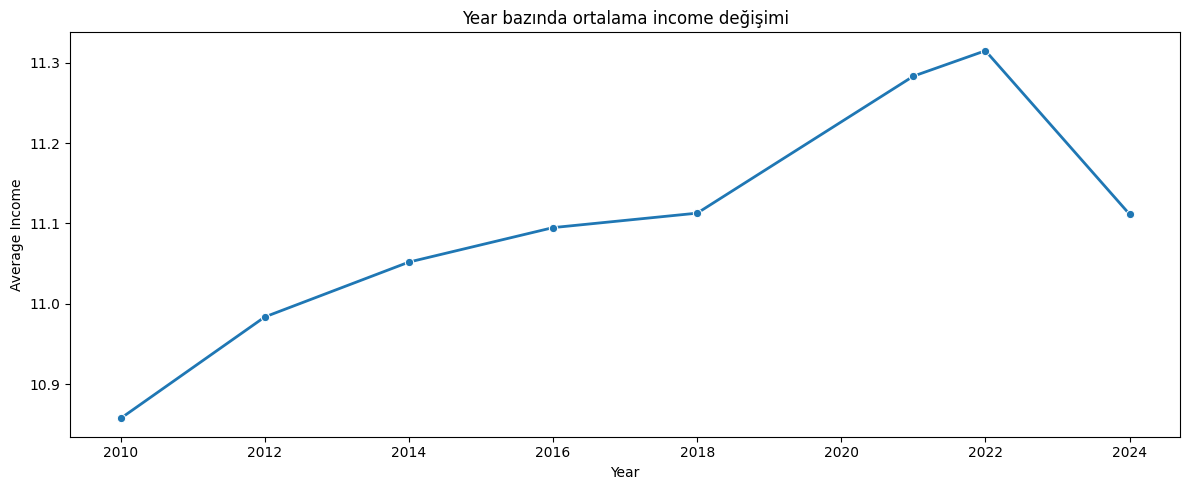

In [51]:
year_income = df.copy()
year_income["income_num"] = year_income["income"].astype(float)
yearly_income = year_income.groupby("year", observed=True)["income_num"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_income, x="year", y="income_num", marker="o", linewidth=2)
plt.title("Year bazında ortalama income değişimi")
plt.xlabel("Year")
plt.ylabel("Average Income")
plt.tight_layout()
plt.show()

Bu çizgi grafiği, yıl bazında ortalama gelir seviyesinin nasıl hareket ettiğini gösterir. Böylece ekonomik dalgalanmaların gelir algısına etkisi daha net izlenebilir.

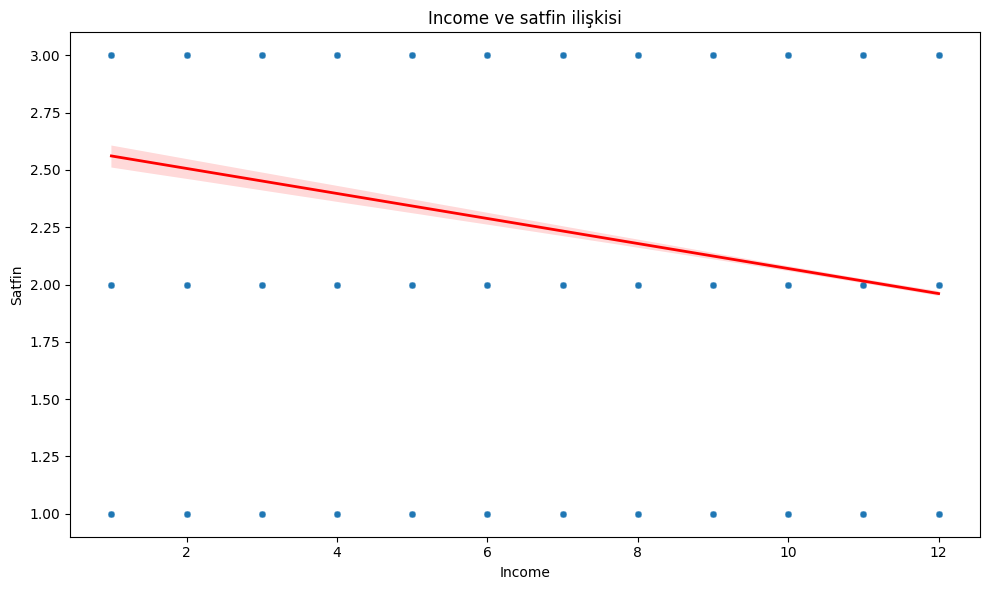

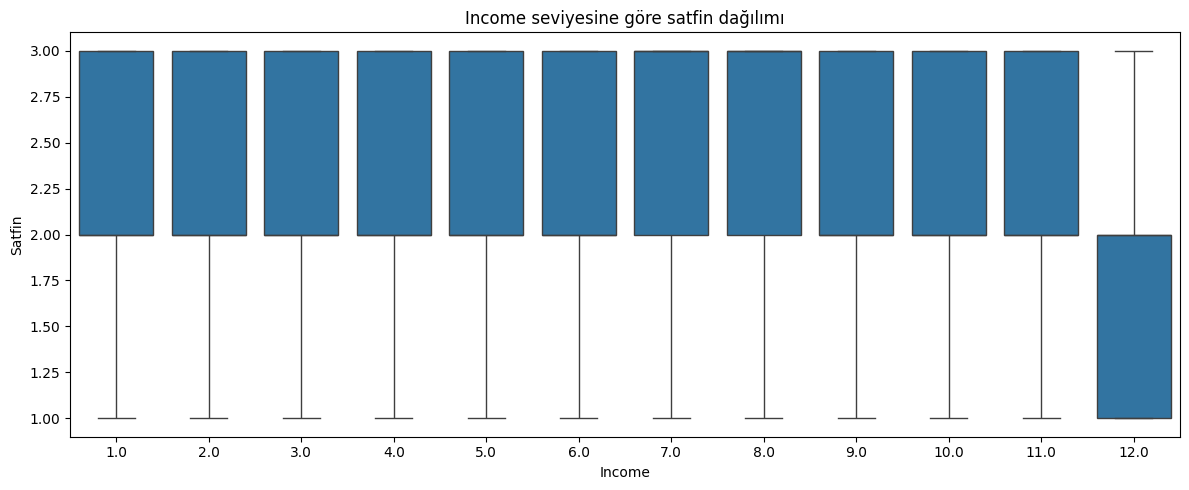

In [52]:
satfin_plot = df.copy()
satfin_plot["income_num"] = satfin_plot["income"].astype(float)
satfin_plot["satfin_num"] = satfin_plot["satfin"].astype(float)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=satfin_plot, x="income_num", y="satfin_num", alpha=0.25, s=25)
sns.regplot(data=satfin_plot, x="income_num", y="satfin_num", scatter=False, color="red", line_kws={"linewidth": 2})
plt.title("Income ve satfin ilişkisi")
plt.xlabel("Income")
plt.ylabel("Satfin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=satfin_plot, x="income_num", y="satfin_num")
plt.title("Income seviyesine göre satfin dağılımı")
plt.xlabel("Income")
plt.ylabel("Satfin")
plt.tight_layout()
plt.show()

YBS gözüyle bakınca bankalar sadece gelire değil, gelirle birlikte finansal tatmin düzeyine de bakmalıdır. Aynı gelir grubundaki farklı tatmin seviyeleri, ürünleri daha hassas segmentlere göre sunmanın daha doğru olacağını gösterir.

Gelir ile finansal memnuniyet arasında tek yönlü ve kusursuz bir doğrusal ilişki beklenmiyor. Grafik, belirli gelir seviyelerinden sonra memnuniyet artışının yavaşladığını düşündürüyor; bu yüzden geliri tek başına yeterli açıklayıcı olarak görmek doğru olmaz.

Para mutluluğu/tatmini getirir mi?" sorusunun veri odaklı cevabıdır.

Hipotez: "Gelir (income) arttıkça, finansal memnuniyet (satfin) doğrusal olarak artıyor mu, yoksa bir noktadan sonra doyuma mı ulaşıyor?"

## Sağlık, Gelir ve Eğitim Etkileşimi

Bu bölümde `health` değişkenini hedef kabul edip `satfin`, `income` ve `educ` ile ilişkisini çapraz tablo mantığında inceliyorum. Kategorik değişkenler olduğu için klasik korelasyon yerine, satır içi yüzdelerle yorumlanabilen heatmap'ler daha doğru bir okuma sağlıyor.

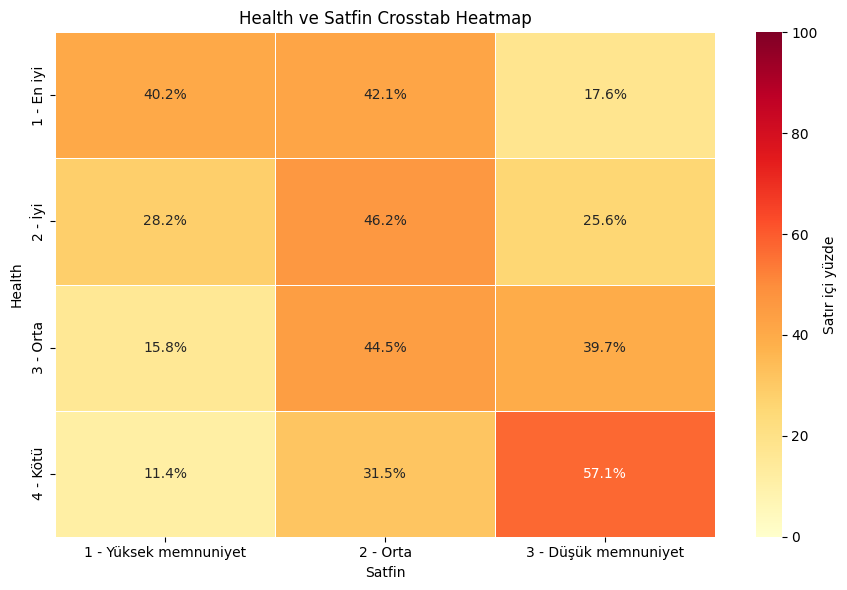

col_0,1 - Yüksek memnuniyet,2 - Orta,3 - Düşük memnuniyet
row_0,,,
1 - En iyi,1596,1671,699
2 - İyi,3796,6211,3449
3 - Orta,643,1808,1612
4 - Kötü,109,301,545


col_0,1 - Yüksek memnuniyet,2 - Orta,3 - Düşük memnuniyet
row_0,,,
1 - En iyi,40.2,42.1,17.6
2 - İyi,28.2,46.2,25.6
3 - Orta,15.8,44.5,39.7
4 - Kötü,11.4,31.5,57.1


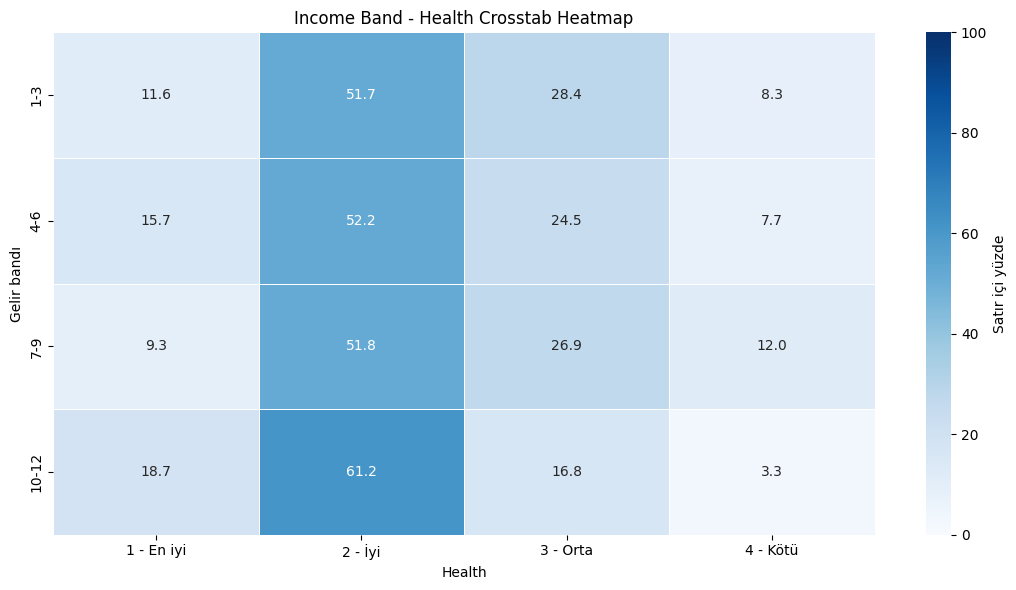

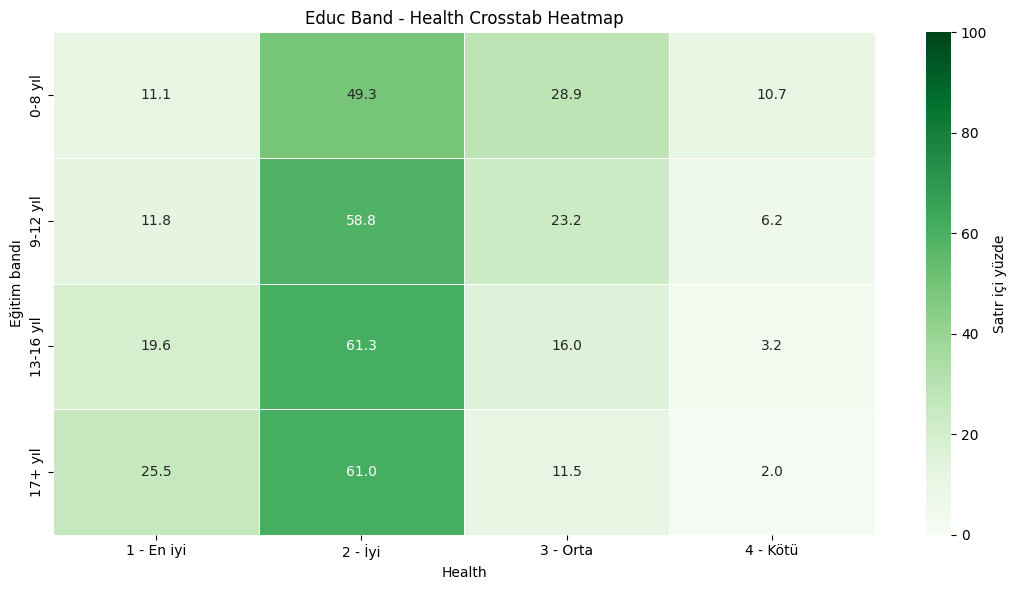

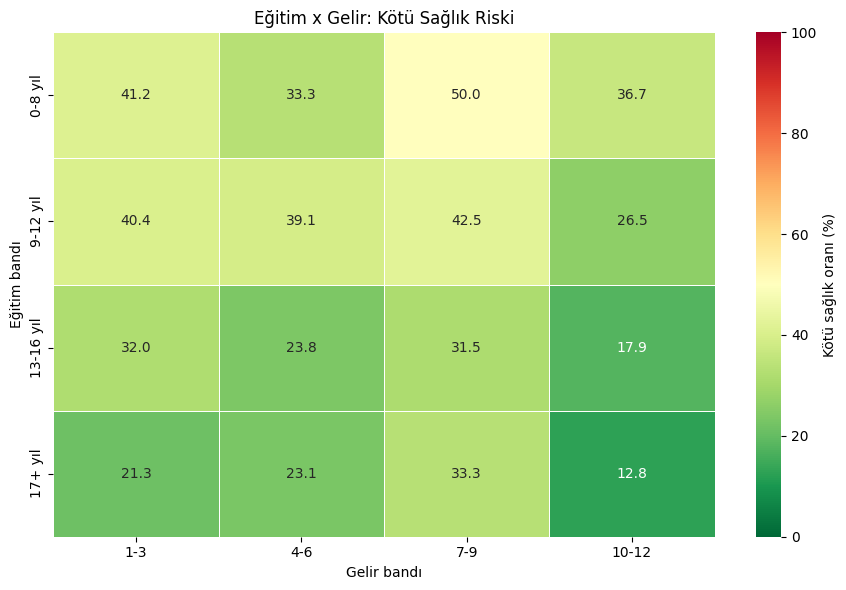

kötü_sağlık_oranı_%
educ_band income_band                     
0-8 yıl   7-9                         50.0
9-12 yıl  7-9                         42.5
0-8 yıl   1-3                         41.2
9-12 yıl  1-3                         40.4
          4-6                         39.1
0-8 yıl   10-12                       36.7
          4-6                         33.3
17+ yıl   7-9                         33.3

In [53]:
analysis_df = df[["health", "satfin", "income", "educ"]].dropna().copy()

analysis_df["health_num"] = pd.to_numeric(analysis_df["health"], errors="coerce").round().astype(int)
analysis_df["satfin_num"] = pd.to_numeric(analysis_df["satfin"], errors="coerce").round().astype(int)
analysis_df["income_num"] = pd.to_numeric(analysis_df["income"], errors="coerce").round().astype(int)
analysis_df["educ_num"] = pd.to_numeric(analysis_df["educ"], errors="coerce").round().astype(int)

health_labels = {
    1: "1 - En iyi",
    2: "2 - İyi",
    3: "3 - Orta",
    4: "4 - Kötü",
}

satfin_labels = {
    1: "1 - Yüksek memnuniyet",
    2: "2 - Orta",
    3: "3 - Düşük memnuniyet",
}

analysis_df["health_label"] = analysis_df["health_num"].map(health_labels)
analysis_df["satfin_label"] = analysis_df["satfin_num"].map(satfin_labels)
analysis_df["income_band"] = pd.cut(
    analysis_df["income_num"],
    bins=[0, 3, 6, 9, 12],
    labels=["1-3", "4-6", "7-9", "10-12"],
    include_lowest=True,
)
analysis_df["educ_band"] = pd.cut(
    analysis_df["educ_num"],
    bins=[-1, 8, 12, 16, 30],
    labels=["0-8 yıl", "9-12 yıl", "13-16 yıl", "17+ yıl"],
    include_lowest=True,
)
analysis_df["poor_health"] = (analysis_df["health_num"] >= 3).astype(int)

health_satfin_pct = pd.crosstab(
    pd.Categorical(
        analysis_df["health_label"],
        categories=[health_labels[key] for key in [1, 2, 3, 4]],
        ordered=True,
    ),
    pd.Categorical(
        analysis_df["satfin_label"],
        categories=[satfin_labels[key] for key in [1, 2, 3]],
        ordered=True,
    ),
    normalize="index",
) * 100
health_satfin_counts = pd.crosstab(
    pd.Categorical(
        analysis_df["health_label"],
        categories=[health_labels[key] for key in [1, 2, 3, 4]],
        ordered=True,
    ),
    pd.Categorical(
        analysis_df["satfin_label"],
        categories=[satfin_labels[key] for key in [1, 2, 3]],
        ordered=True,
    ),
)

income_health_pct = pd.crosstab(
    pd.Categorical(analysis_df["income_band"], categories=["1-3", "4-6", "7-9", "10-12"], ordered=True),
    pd.Categorical(
        analysis_df["health_label"],
        categories=[health_labels[key] for key in [1, 2, 3, 4]],
        ordered=True,
    ),
    normalize="index",
) * 100

educ_health_pct = pd.crosstab(
    pd.Categorical(analysis_df["educ_band"], categories=["0-8 yıl", "9-12 yıl", "13-16 yıl", "17+ yıl"], ordered=True),
    pd.Categorical(
        analysis_df["health_label"],
        categories=[health_labels[key] for key in [1, 2, 3, 4]],
        ordered=True,
    ),
    normalize="index",
) * 100

risk_heatmap = analysis_df.pivot_table(
    index="educ_band",
    columns="income_band",
    values="poor_health",
    aggfunc="mean",
) * 100

plt.figure(figsize=(9, 6))
sns.heatmap(
    health_satfin_pct,
    annot=health_satfin_pct.round(1).astype(str) + "%",
    fmt="",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Satır içi yüzde"},
)
plt.title("Health ve Satfin Crosstab Heatmap")
plt.xlabel("Satfin")
plt.ylabel("Health")
plt.tight_layout()
plt.show()

display(health_satfin_counts)

display(health_satfin_pct.round(1))

plt.figure(figsize=(11, 6))
sns.heatmap(
    income_health_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Satır içi yüzde"},
)
plt.title("Income Band - Health Crosstab Heatmap")
plt.xlabel("Health")
plt.ylabel("Gelir bandı")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.heatmap(
    educ_health_pct,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Satır içi yüzde"},
)
plt.title("Educ Band - Health Crosstab Heatmap")
plt.xlabel("Health")
plt.ylabel("Eğitim bandı")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.heatmap(
    risk_heatmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Kötü sağlık oranı (%)"},
)
plt.title("Eğitim x Gelir: Kötü Sağlık Riski")
plt.xlabel("Gelir bandı")
plt.ylabel("Eğitim bandı")
plt.tight_layout()
plt.show()

risk_top = risk_heatmap.stack().sort_values(ascending=False).head(8).to_frame("kötü_sağlık_oranı_%")
display(risk_top.round(1))

Bu grafikler üç şeyi gösteriyor: sağlık memnuniyetsizliği arttıkça finansal memnuniyet dağılımı da kötüleşiyor; gelir bandı yükseldikçe kötü sağlık payı düşüyor; eğitim seviyesi de aynı yönde koruyucu etki gösteriyor. Özellikle düşük eğitim ve düşük gelir kesişimi, dijital sağlık hizmeti veya özel sağlık sigortası hedeflemelerinde en yüksek riskli segment olarak öne çıkıyor.
Hipotez: "Eğitim (educ) ve Gelir (income), Sağlık (health) durumunu nasıl etkiliyor?"

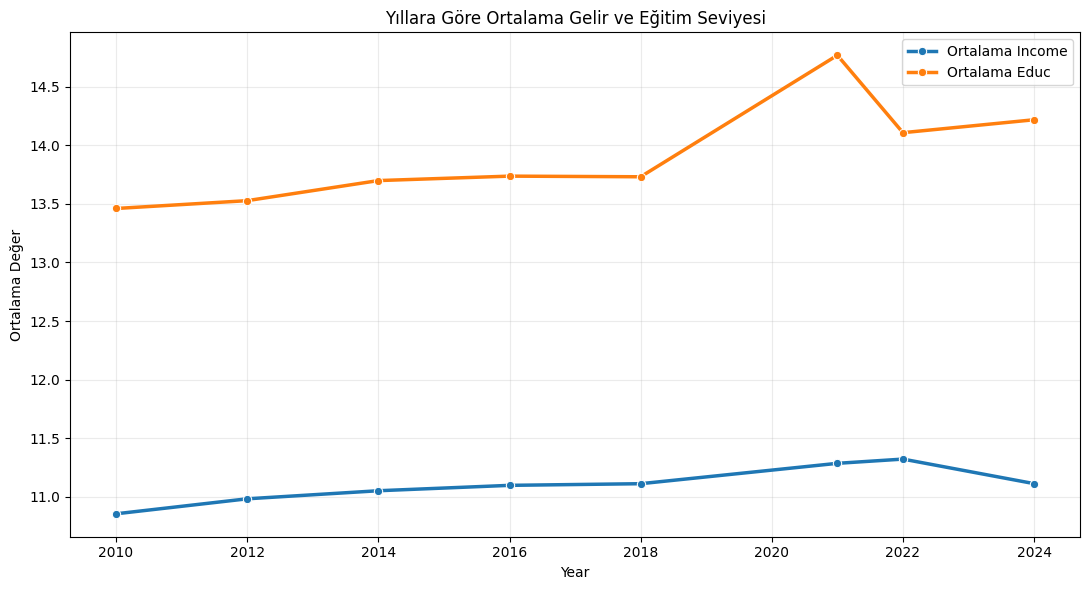

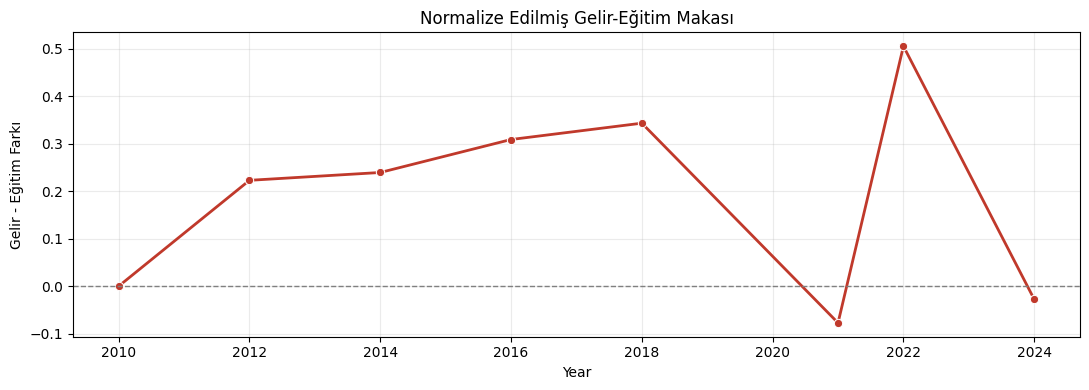

,year,avg_income,avg_educ,income_norm,educ_norm,gap_index
0,2010,10.855,13.461,0.000,0.000,0.000
1,2012,10.983,13.528,0.274,0.051,0.223
2,2014,11.052,13.699,0.421,0.182,0.239
3,2016,11.098,13.737,0.520,0.211,0.309
4,2018,11.112,13.732,0.550,0.207,0.343
5,2021,11.286,14.769,0.923,1.000,-0.077
6,2022,11.322,14.108,1.000,0.495,0.505
7,2024,11.112,14.219,0.551,0.579,-0.028


In [54]:
year_trend = df[["year", "income", "educ"]].copy()
year_trend["year"] = pd.to_numeric(year_trend["year"], errors="coerce").astype("Int64")
year_trend["income_num"] = pd.to_numeric(year_trend["income"], errors="coerce")
year_trend["educ_num"] = pd.to_numeric(year_trend["educ"], errors="coerce")
year_trend = year_trend.dropna(subset=["year", "income_num", "educ_num"])

yearly_trend = (
    year_trend.groupby("year", as_index=False)
    .agg(avg_income=("income_num", "mean"), avg_educ=("educ_num", "mean"))
    .sort_values("year")
)

yearly_trend["income_norm"] = (yearly_trend["avg_income"] - yearly_trend["avg_income"].min()) / (
    yearly_trend["avg_income"].max() - yearly_trend["avg_income"].min()
)
yearly_trend["educ_norm"] = (yearly_trend["avg_educ"] - yearly_trend["avg_educ"].min()) / (
    yearly_trend["avg_educ"].max() - yearly_trend["avg_educ"].min()
)
yearly_trend["gap_index"] = yearly_trend["income_norm"] - yearly_trend["educ_norm"]

plt.figure(figsize=(11, 6))
sns.lineplot(data=yearly_trend, x="year", y="avg_income", marker="o", linewidth=2.5, label="Ortalama Income")
sns.lineplot(data=yearly_trend, x="year", y="avg_educ", marker="o", linewidth=2.5, label="Ortalama Educ")
plt.title("Yıllara Göre Ortalama Gelir ve Eğitim Seviyesi")
plt.xlabel("Year")
plt.ylabel("Ortalama Değer")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
sns.lineplot(data=yearly_trend, x="year", y="gap_index", marker="o", linewidth=2, color="#C0392B")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Normalize Edilmiş Gelir-Eğitim Makası")
plt.xlabel("Year")
plt.ylabel("Gelir - Eğitim Farkı")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(yearly_trend.round(3))

## Yıllar İçinde Makas Analizi

Yıllar içinde eğitim seviyesi ve gelir arasındaki makas açıldı mı yoksa daraldı mı?

Çizgi grafiği, eğitim seviyesinin yıllar içinde gelirden biraz daha hızlı yükseldiğini; ancak bu ayrışmanın her yıl aynı yönde ilerlemediğini gösteriyor. Kısacası makas tamamen kapanmış değil, fakat dönemsel olarak daralıp açılan dalgalı bir yapı var.

YBS iş analisti gözüyle bu tablo, bankalar için daha sofistike kredi skorlama ihtiyacına işaret eder: sadece gelir düzeyi değil, eğitim artışının gelir artışına ne kadar yansıdığı da izlenmelidir. Devlet tarafında ise sosyal yardım stratejileri düşük eğitim ve düşük gelirli gruplarda daha yoğun, hedefli ve dijital erişim destekli tasarlanmalıdır; çünkü bu segmentler hem ekonomik hem de hizmet erişimi açısından daha kırılgan görünür.
